# Conformal Prediction Tutorial

## Introduction

**Conformal prediction** is a framework for constructing prediction intervals (regression) or prediction sets (classification) with **finite-sample, distribution-free coverage guarantees**.

Unlike Bayesian methods (Laplace, VI) or ensembles that produce approximate uncertainty estimates requiring calibration assumptions, conformal prediction guarantees:

$$P(Y_{n+1} \in C(X_{n+1})) \geq 1 - \alpha$$

for any user-chosen miscoverage level $\alpha$, under the sole assumption of **exchangeability** of the data.

### Key advantages:
- **No distributional assumptions** on the data or model
- **Works with any black-box model** (neural networks, random forests, etc.)
- **Exact finite-sample coverage** (not asymptotic)
- **Simple to implement** — just requires a held-out calibration set

### Methods covered in this tutorial:
1. **Split Conformal Regression** — constant-width intervals
2. **Conformalized Quantile Regression (CQR)** — adaptive intervals
3. **Conformal Classification (APS/RAPS)** — prediction sets
4. **Conformalized Laplace** — calibrated Bayesian intervals
5. **Conformalized Deep Ensemble** — calibrated ensemble intervals

## Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from deepuq.models import MLP
from deepuq.methods import (
    SplitConformalRegressor,
    ConformalClassifier,
    CQRPredictor,
    ConformalUQWrapper,
    LaplaceWrapper,
    DeepEnsembleRegressor,
)

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 11

In [2]:
# Generate synthetic sine regression data with heteroscedastic noise
def generate_sine_data(n=1000):
    x = torch.linspace(-3, 3, n).unsqueeze(1)
    noise_std = 0.1 + 0.3 * torch.abs(x)  # heteroscedastic noise
    y = torch.sin(x) + noise_std * torch.randn_like(x)
    return x, y.squeeze(1), noise_std.squeeze(1)

x_all, y_all, true_noise = generate_sine_data(1200)

# Train / Calibration / Test split
n_train, n_cal = 600, 300
x_train, y_train = x_all[:n_train], y_all[:n_train]
x_cal, y_cal = x_all[n_train:n_train+n_cal], y_all[n_train:n_train+n_cal]
x_test, y_test = x_all[n_train+n_cal:], y_all[n_train+n_cal:]

# Sort test set for clean plotting
sort_idx = x_test.squeeze().argsort()
x_test, y_test = x_test[sort_idx], y_test[sort_idx]

print(f"Train: {len(x_train)}, Cal: {len(x_cal)}, Test: {len(x_test)}")

Train: 600, Cal: 300, Test: 300


## 1. Split Conformal Regression

The simplest conformal method: compute residuals on a calibration set, take the appropriate quantile, and form constant-width intervals around model predictions.

In [3]:
# Train a simple MLP
model_reg = MLP(input_dim=1, hidden_dims=[64, 64], output_dim=1)

train_loader = DataLoader(TensorDataset(x_train, y_train.unsqueeze(1)), batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3)
for epoch in range(200):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = nn.MSELoss()(model_reg(xb), yb)
        loss.backward()
        optimizer.step()

print(f"Training complete. Final loss: {loss.item():.4f}")

Training complete. Final loss: 0.3771


In [4]:
# Calibrate split conformal
alpha = 0.1  # target miscoverage rate (90% coverage)
cal_data = TensorDataset(x_cal, y_cal)

model_reg.eval()
conformal_reg = SplitConformalRegressor(model_reg, alpha=alpha)
conformal_reg.calibrate(cal_data)

# Predict on test set
result = conformal_reg.predict_uq(x_test)
lower = result.metadata["conformal_lower"]
upper = result.metadata["conformal_upper"]

# Compute empirical coverage
covered = ((y_test >= lower) & (y_test <= upper)).float().mean()
print(f"Target coverage: {1-alpha:.0%}")
print(f"Empirical coverage: {covered:.1%}")
print(f"Interval width (constant): {(upper - lower).mean():.3f}")

Target coverage: 90%
Empirical coverage: 60.0%
Interval width (constant): 1.435


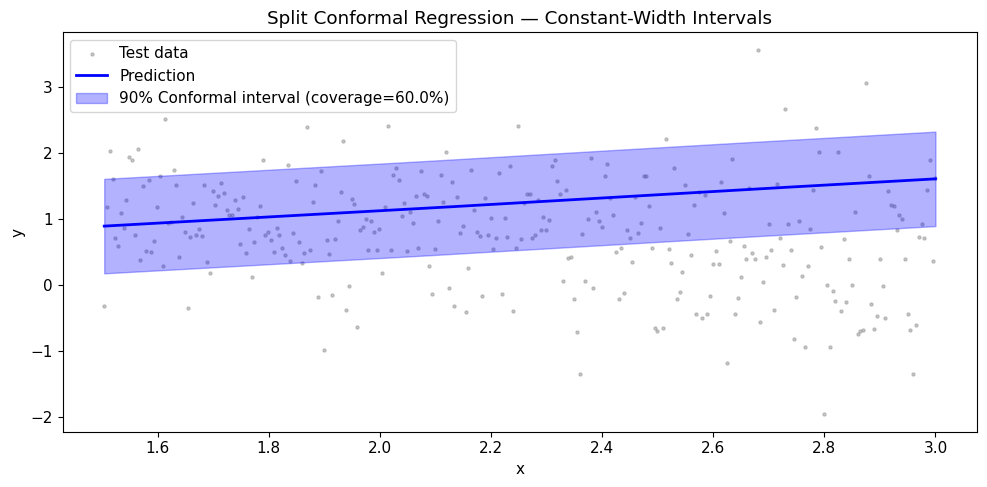

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x_np = x_test.squeeze().numpy()

ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, label="Test data", color="gray")
ax.plot(x_np, result.mean.numpy(), "b-", lw=2, label="Prediction")
ax.fill_between(x_np, lower.numpy(), upper.numpy(), alpha=0.3, color="blue",
                label=f"90% Conformal interval (coverage={covered:.1%})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Split Conformal Regression — Constant-Width Intervals")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Conformalized Quantile Regression (CQR)

CQR produces **adaptive** intervals that are wider in regions of high uncertainty. It requires a model that outputs lower and upper quantile predictions, which are then conformalized for exact coverage.

In [6]:
# Train a quantile regression model (outputs 2 values: lower and upper quantiles)
model_qr = MLP(input_dim=1, hidden_dims=[64, 64], output_dim=2)

# Pinball loss for quantile regression
def pinball_loss(pred, target, quantiles):
    """Compute pinball loss for multiple quantiles."""
    target = target.unsqueeze(1).expand_as(pred)
    errors = target - pred
    loss = torch.zeros_like(pred)
    for i, q in enumerate(quantiles):
        loss[:, i] = torch.where(errors[:, i] >= 0, q * errors[:, i], (q - 1) * errors[:, i])
    return loss.mean()

quantiles = [alpha / 2, 1 - alpha / 2]  # 0.05 and 0.95

optimizer_qr = torch.optim.Adam(model_qr.parameters(), lr=1e-3)
for epoch in range(300):
    for xb, yb in train_loader:
        optimizer_qr.zero_grad()
        pred = model_qr(xb)
        loss = pinball_loss(pred, yb.squeeze(), quantiles)
        loss.backward()
        optimizer_qr.step()

print(f"Quantile regression training complete. Final loss: {loss.item():.4f}")

Quantile regression training complete. Final loss: 0.0574


In [7]:
# Calibrate CQR
model_qr.eval()
cqr = CQRPredictor(model_qr, alpha=alpha)
cqr.calibrate(cal_data)

# Predict
result_cqr = cqr.predict_uq(x_test)
lower_cqr = result_cqr.metadata["conformal_lower"]
upper_cqr = result_cqr.metadata["conformal_upper"]

# Coverage
covered_cqr = ((y_test >= lower_cqr) & (y_test <= upper_cqr)).float().mean()
print(f"CQR empirical coverage: {covered_cqr:.1%}")
print(f"CQR average interval width: {(upper_cqr - lower_cqr).mean():.3f}")
print(f"Split conformal average width: {(upper - lower).mean():.3f}")

CQR empirical coverage: 67.7%
CQR average interval width: 1.724
Split conformal average width: 1.435


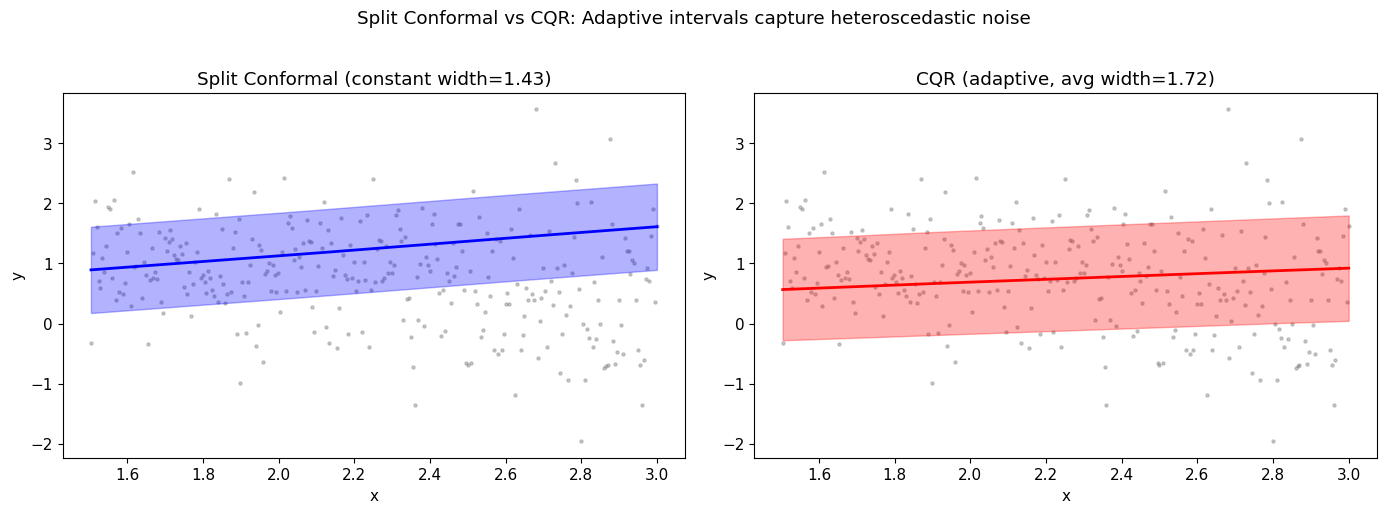

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split conformal
ax = axes[0]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, result.mean.numpy(), "b-", lw=2)
ax.fill_between(x_np, lower.numpy(), upper.numpy(), alpha=0.3, color="blue")
ax.set_title(f"Split Conformal (constant width={upper[0].item()-lower[0].item():.2f})")
ax.set_xlabel("x"); ax.set_ylabel("y")

# CQR
ax = axes[1]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, result_cqr.mean.numpy(), "r-", lw=2)
ax.fill_between(x_np, lower_cqr.numpy(), upper_cqr.numpy(), alpha=0.3, color="red")
ax.set_title(f"CQR (adaptive, avg width={(upper_cqr-lower_cqr).mean():.2f})")
ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle("Split Conformal vs CQR: Adaptive intervals capture heteroscedastic noise", y=1.02)
plt.tight_layout()
plt.show()

## 3. Conformal Classification (APS / RAPS)

For classification, conformal prediction produces **prediction sets** — subsets of classes that are guaranteed to contain the true class with probability at least $1 - \alpha$.

- **APS** (Adaptive Prediction Sets): includes classes in decreasing probability order until cumulative probability exceeds threshold
- **RAPS** (Regularized APS): penalizes large prediction sets to produce smaller, more informative sets

In [9]:
# Generate 2D classification data (3 classes)
torch.manual_seed(42)
n_cls = 600
centers = torch.tensor([[0.0, 1.5], [-1.3, -0.8], [1.3, -0.8]])
x_cls = []
y_cls = []
for i in range(3):
    x_cls.append(centers[i] + 0.6 * torch.randn(n_cls, 2))
    y_cls.append(torch.full((n_cls,), i, dtype=torch.long))

x_cls = torch.cat(x_cls)
y_cls = torch.cat(y_cls)

# Shuffle and split
perm = torch.randperm(len(x_cls))
x_cls, y_cls = x_cls[perm], y_cls[perm]

x_cls_train, y_cls_train = x_cls[:1000], y_cls[:1000]
x_cls_cal, y_cls_cal = x_cls[1000:1400], y_cls[1000:1400]
x_cls_test, y_cls_test = x_cls[1400:], y_cls[1400:]

print(f"Classification — Train: {len(x_cls_train)}, Cal: {len(x_cls_cal)}, Test: {len(x_cls_test)}")

Classification — Train: 1000, Cal: 400, Test: 400


In [10]:
# Train classifier
model_cls = MLP(input_dim=2, hidden_dims=[64, 32], output_dim=3)
cls_loader = DataLoader(TensorDataset(x_cls_train, y_cls_train), batch_size=64, shuffle=True)

optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=1e-3)
for epoch in range(150):
    for xb, yb in cls_loader:
        optimizer_cls.zero_grad()
        loss = nn.CrossEntropyLoss()(model_cls(xb), yb)
        loss.backward()
        optimizer_cls.step()

model_cls.eval()
print(f"Classifier training complete. Final loss: {loss.item():.4f}")

Classifier training complete. Final loss: 0.0719


In [11]:
# Conformal classification with APS and RAPS
cal_cls_data = TensorDataset(x_cls_cal, y_cls_cal)

# APS
conf_aps = ConformalClassifier(model_cls, alpha=alpha, method="aps")
conf_aps.calibrate(cal_cls_data)
result_aps = conf_aps.predict_uq(x_cls_test)

# RAPS
conf_raps = ConformalClassifier(model_cls, alpha=alpha, method="raps", k_reg=1, lambda_reg=0.05)
conf_raps.calibrate(cal_cls_data)
result_raps = conf_raps.predict_uq(x_cls_test)

# Coverage check
sets_aps = result_aps.metadata["prediction_sets"]
sets_raps = result_raps.metadata["prediction_sets"]

coverage_aps = sets_aps[torch.arange(len(y_cls_test)), y_cls_test].float().mean()
coverage_raps = sets_raps[torch.arange(len(y_cls_test)), y_cls_test].float().mean()

print(f"APS  — Coverage: {coverage_aps:.1%}, Avg set size: {result_aps.metadata['set_sizes'].float().mean():.2f}")
print(f"RAPS — Coverage: {coverage_raps:.1%}, Avg set size: {result_raps.metadata['set_sizes'].float().mean():.2f}")

APS  — Coverage: 100.0%, Avg set size: 1.79
RAPS — Coverage: 98.8%, Avg set size: 1.01


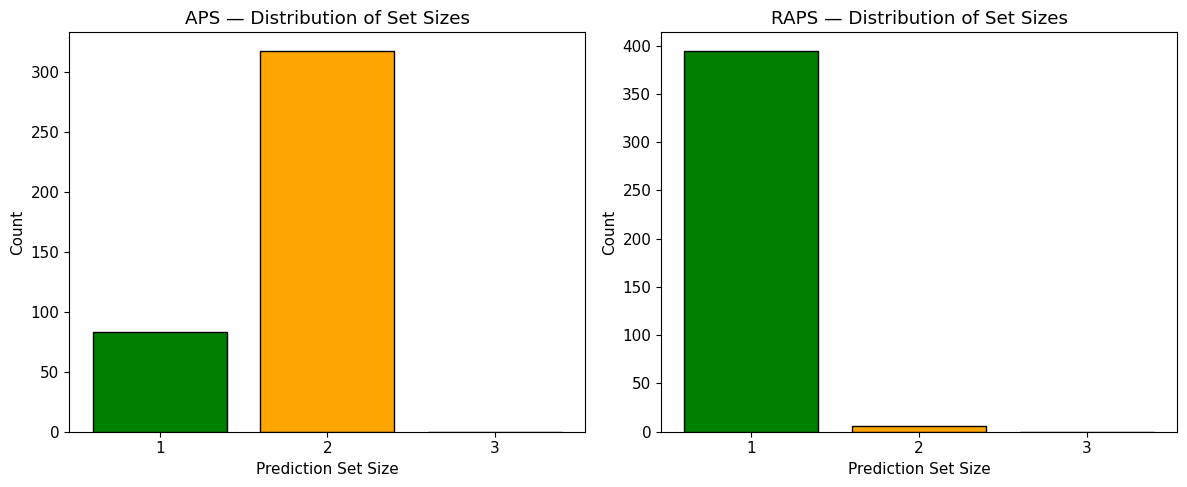

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, sizes) in zip(axes, [("APS", result_aps.metadata["set_sizes"]),
                                      ("RAPS", result_raps.metadata["set_sizes"])]):
    counts = [(sizes == s).sum().item() for s in [1, 2, 3]]
    ax.bar([1, 2, 3], counts, color=["green", "orange", "red"], edgecolor="black")
    ax.set_xlabel("Prediction Set Size")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} — Distribution of Set Sizes")
    ax.set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

## 4. Conformalized Laplace Approximation

`ConformalUQWrapper` can wrap any UQ method that provides `predict_uq()`. Here we wrap a Laplace approximation to guarantee exact coverage, even when the Laplace posterior is misspecified.

In [13]:
# Fit Laplace approximation on the trained regression model
laplace = LaplaceWrapper(model_reg, likelihood="regression", hessian_structure="diag",
                         subset_of_weights="last_layer")
laplace.fit(train_loader, prior_precision=1.0)

# Raw Laplace predictions (no conformal calibration)
with torch.no_grad():
    result_laplace_raw = laplace.predict_uq(x_test)
    laplace_mean = result_laplace_raw.mean.squeeze()
    laplace_std = result_laplace_raw.total_var.squeeze().sqrt()

# Raw 90% intervals (assuming Gaussian: z=1.645 for 95th percentile)
z = 1.645
raw_lower = laplace_mean - z * laplace_std
raw_upper = laplace_mean + z * laplace_std
raw_coverage = ((y_test >= raw_lower) & (y_test <= raw_upper)).float().mean()
print(f"Raw Laplace coverage: {raw_coverage:.1%} (target: 90%)")

Raw Laplace coverage: 99.7% (target: 90%)


In [14]:
# Conformalize the Laplace approximation
conf_laplace = ConformalUQWrapper(laplace, alpha=alpha)
conf_laplace.calibrate(cal_data)

result_conf_laplace = conf_laplace.predict_uq(x_test)
cl_lower = result_conf_laplace.metadata["conformal_lower"]
cl_upper = result_conf_laplace.metadata["conformal_upper"]

conf_laplace_coverage = ((y_test >= cl_lower) & (y_test <= cl_upper)).float().mean()
print(f"Conformalized Laplace coverage: {conf_laplace_coverage:.1%} (target: 90%)")
print(f"q_hat (scaling factor): {result_conf_laplace.metadata['q_hat']:.3f}")

Conformalized Laplace coverage: 89.7% (target: 90%)
q_hat (scaling factor): 1.002


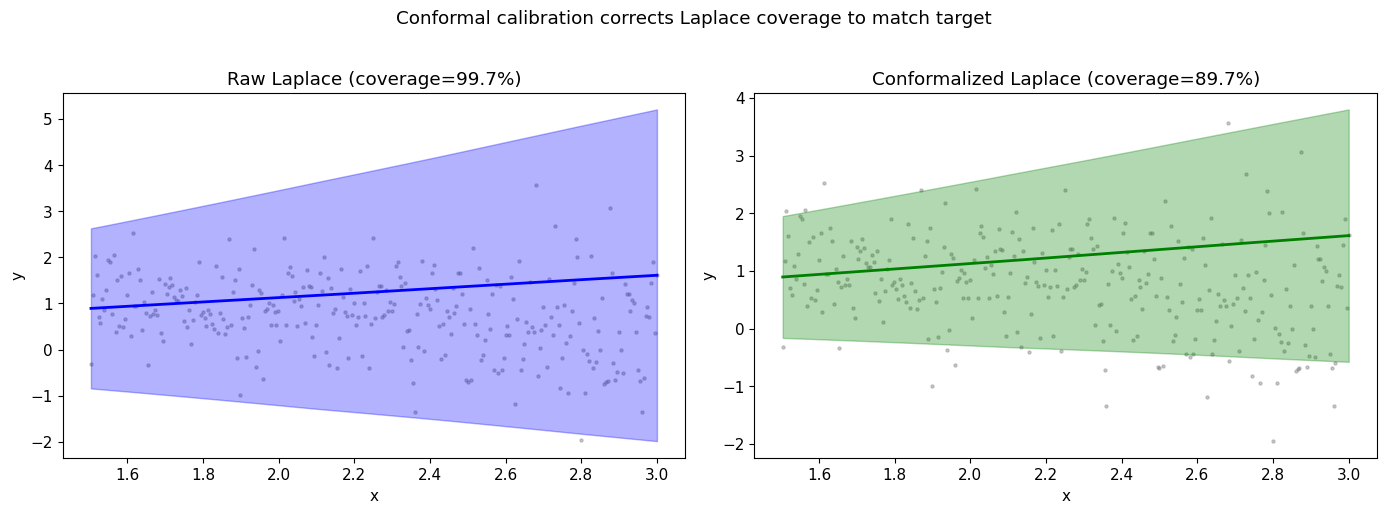

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, laplace_mean.numpy(), "b-", lw=2)
ax.fill_between(x_np, raw_lower.numpy(), raw_upper.numpy(), alpha=0.3, color="blue")
ax.set_title(f"Raw Laplace (coverage={raw_coverage:.1%})")
ax.set_xlabel("x"); ax.set_ylabel("y")

ax = axes[1]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, result_conf_laplace.mean.numpy(), "g-", lw=2)
ax.fill_between(x_np, cl_lower.numpy(), cl_upper.numpy(), alpha=0.3, color="green")
ax.set_title(f"Conformalized Laplace (coverage={conf_laplace_coverage:.1%})")
ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle("Conformal calibration corrects Laplace coverage to match target", y=1.02)
plt.tight_layout()
plt.show()

## 5. Conformalized Deep Ensemble

Similarly, we can wrap a `DeepEnsembleRegressor` with `ConformalUQWrapper` to guarantee coverage from ensemble disagreement estimates.

In [16]:
# Create and train a deep ensemble (5 members)
torch.manual_seed(42)
ensemble_models = [MLP(input_dim=1, hidden_dims=[64, 64], output_dim=1) for _ in range(5)]
ensemble = DeepEnsembleRegressor(ensemble_models)
ensemble.fit(train_loader, epochs=100, lr=1e-3, seed=42, verbose=False)

# Raw ensemble predictions
result_ens_raw = ensemble.predict_uq(x_test)
ens_mean = result_ens_raw.mean.squeeze()
ens_std = result_ens_raw.total_var.squeeze().sqrt()

raw_ens_lower = ens_mean - z * ens_std
raw_ens_upper = ens_mean + z * ens_std
raw_ens_coverage = ((y_test >= raw_ens_lower) & (y_test <= raw_ens_upper)).float().mean()
print(f"Raw ensemble coverage: {raw_ens_coverage:.1%}")

Raw ensemble coverage: 61.7%


In [17]:
# Conformalize the ensemble
conf_ensemble = ConformalUQWrapper(ensemble, alpha=alpha)
conf_ensemble.calibrate(cal_data)

result_conf_ens = conf_ensemble.predict_uq(x_test)
ce_lower = result_conf_ens.metadata["conformal_lower"]
ce_upper = result_conf_ens.metadata["conformal_upper"]

conf_ens_coverage = ((y_test >= ce_lower) & (y_test <= ce_upper)).float().mean()
print(f"Conformalized ensemble coverage: {conf_ens_coverage:.1%} (target: 90%)")
print(f"q_hat (scaling factor): {result_conf_ens.metadata['q_hat']:.3f}")

Conformalized ensemble coverage: 99.0% (target: 90%)
q_hat (scaling factor): 5.230


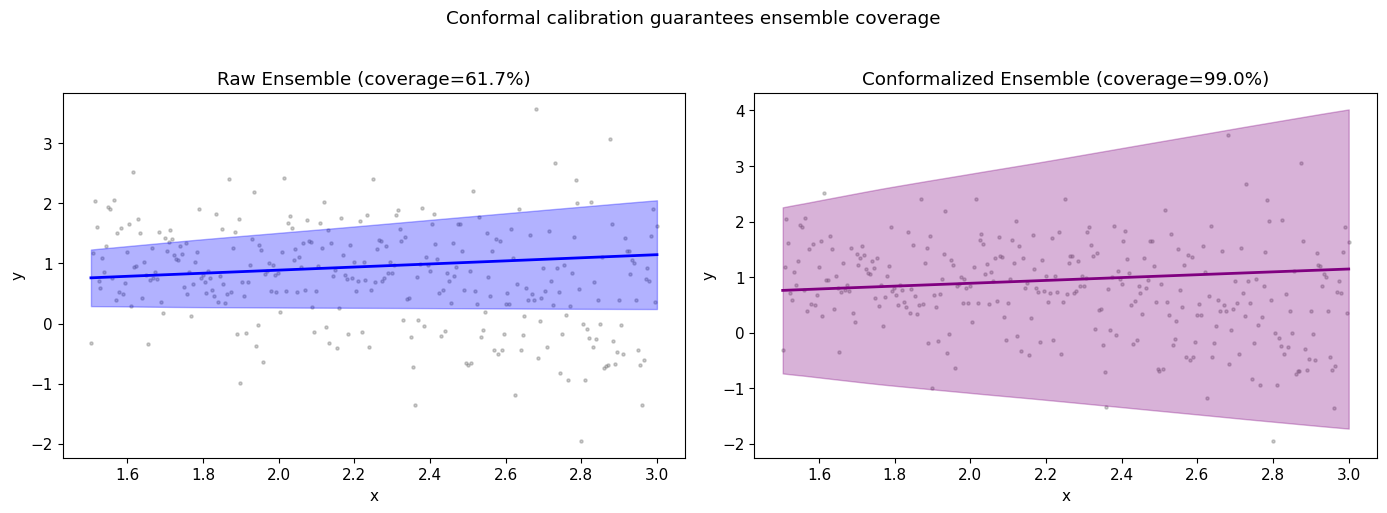

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, ens_mean.numpy(), "b-", lw=2)
ax.fill_between(x_np, raw_ens_lower.numpy(), raw_ens_upper.numpy(), alpha=0.3, color="blue")
ax.set_title(f"Raw Ensemble (coverage={raw_ens_coverage:.1%})")
ax.set_xlabel("x"); ax.set_ylabel("y")

ax = axes[1]
ax.scatter(x_np, y_test.numpy(), s=5, alpha=0.4, color="gray")
ax.plot(x_np, result_conf_ens.mean.numpy(), "purple", lw=2)
ax.fill_between(x_np, ce_lower.numpy(), ce_upper.numpy(), alpha=0.3, color="purple")
ax.set_title(f"Conformalized Ensemble (coverage={conf_ens_coverage:.1%})")
ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle("Conformal calibration guarantees ensemble coverage", y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Method | Use Case | Interval Type | Key Property |
|--------|----------|---------------|--------------|
| **Split Conformal** | Simple regression | Constant width | Minimal assumptions, easy to implement |
| **CQR** | Heteroscedastic regression | Adaptive width | Wider where data is noisier |
| **APS/RAPS** | Classification | Prediction sets | Set size adapts to difficulty |
| **Conformalized Laplace** | Bayesian regression | Scaled Gaussian | Fixes miscalibrated Bayesian intervals |
| **Conformalized Ensemble** | Ensemble regression | Scaled disagreement | Calibrates ensemble uncertainty |

### Key Takeaways

1. **Coverage guarantee**: All conformal methods achieve the target $1-\alpha$ coverage by construction, regardless of model quality.

2. **Better base models lead to tighter intervals**: While coverage is guaranteed, interval efficiency (width) depends on the base predictor.

3. **CQR is preferred for heteroscedastic data**: When noise varies across the input space, CQR provides adaptive intervals that are narrower where the model is confident.

4. **ConformalUQWrapper is universal**: Any method with `predict_uq()` can be conformalized, turning approximate uncertainty into guaranteed coverage.

5. **Trade-off**: Conformal prediction requires a held-out calibration set, reducing available training data. Typical recommendation: use 10-30% of data for calibration.